# Problem 1: Data From yFinance 

## Using the yfinance Python package write a function called get_data()

## That downloads all hourly data from the previous five days
## For the five FAANG stocks
## Facebook (META)
## Apple (AAPL)
## Amazon (AMZN)
## Netflix (NFLX)
## Google (GOOG)


In [7]:
pip install yfinance


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Using def get_data function to download hourly data from the last 5 days
# ans saving as data/YYYYMMDD-HHMMSS.csv and return the file path
import os
from datetime import datetime
import pandas as pd    # Data 
import yfinance as yf  # Yahoo Finance data.
 
def get_data():

# List of tickers
    tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']


    data = {}

    for ticker in tickers:
        stock = yf.Ticker(ticker)
        df = stock.history(period='5d', interval='1h')
        data[ticker] = df

# combine all data into one DataFrame with a ticker column to ensure clear and easily readable 
combined = pd.concat(data.values(), keys=data.keys(), names=['Ticker', 'Datetime'])

price_cols = ['Open', 'High', 'Low', 'Close'] 
combined[price_cols] = combined[price_cols].round(2)

# ensure output directory ists
os.makedirs('data', exist_ok=True)

# timestamped filename
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
filename = f"data/{timestamp}.csv"


# Save the data and combine
combined.to_csv(filename)

# Save and round to 2 decimal places
# Round function from w3schools - https://www.w3schools.com/python/ref_func_round.asp
combined = combined.round(2)

print(f" Data saved to {filename}")



 Data saved to data/20251122-142424.csv


# Problem 2 : Plotting Data



/tmp/ipykernel_89051/809046735.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers,period='1mo')['Close']
[*********************100%***********************]  5 of 5 completed


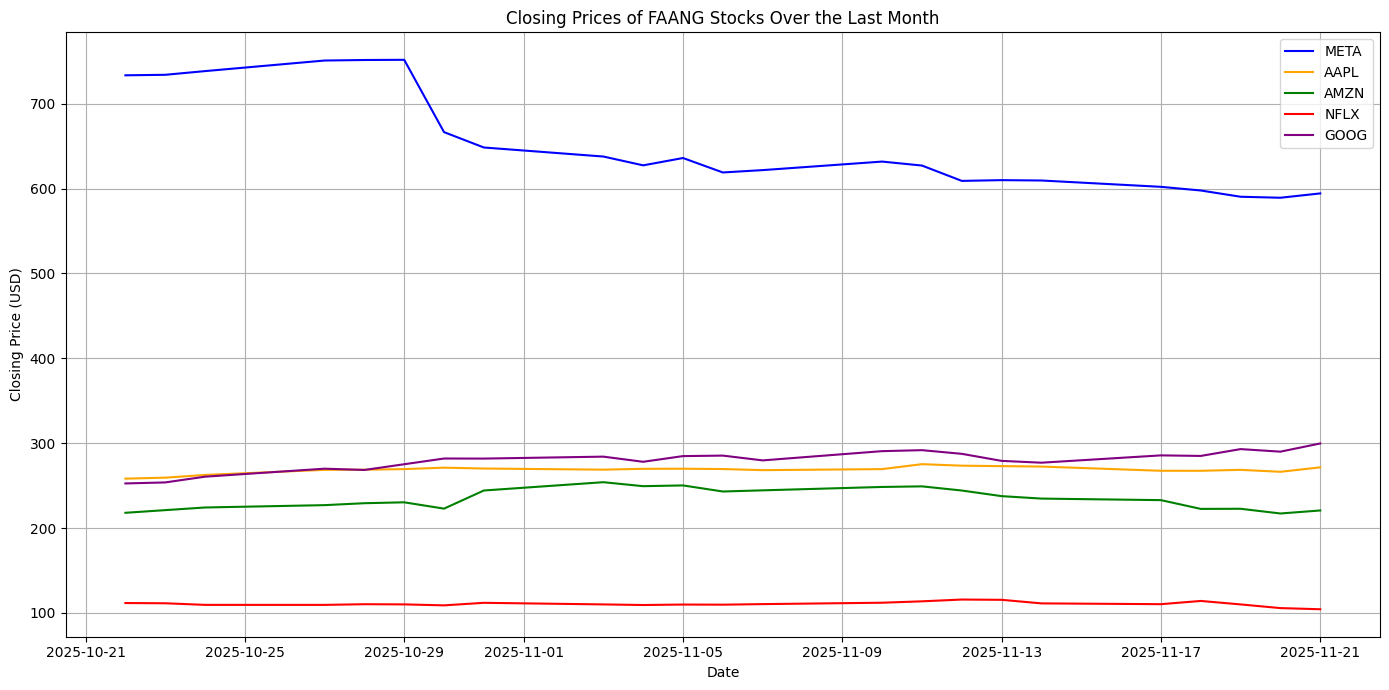

In [4]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt

# Define Tickers
tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

# Download historical data for the last month
# yfinance download function - https://pypi.org/project/yfinance/
df = yf.download(tickers,period='1mo')['Close']

# Plotting the closing prices
plt.figure(figsize=(14,7))
colors = ['blue', 'orange', 'green', 'red', 'purple']   

for ticker, color in zip(tickers, colors):
    plt.plot(df.index, df[ticker], label=ticker, color=color)

# Customize the plot using Matplotlib
# matplotlib - https://www.w3schools.com/python/matplotlib_plotting.asp
plt.title('Closing Prices of FAANG Stocks Over the Last Month')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('stock_prices.png', dpi=300)
plt.show()
